# 資料準備

## 下載資料集

In [1]:
# > 執行下載腳本 (會自動檢查檔案是否已存在)
from scripts.download_data import download_and_sample_data
download_and_sample_data()

# @ 讀取並預覽資料
import pandas as pd
df = pd.read_csv("data/songs.csv")
df.head()


d:\台北市立大學 資訊科學系 在職專班\碩一\上學期\資料探勘\final_spotify\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


// @ 偵測到資料集已存在於 data/songs.csv，跳過下載步驟。


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,113186,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50,440247,False,0.369,0.598,...,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
1,42819,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11,93933,False,0.171,0.997,...,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
2,59311,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0,213578,False,0.173,0.803,...,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
3,91368,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0,151387,False,0.683,0.511,...,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
4,61000,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,57,236293,False,0.555,0.941,...,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


## 數值特徵處理

In [2]:
# > 呼叫模組化前處理腳本
from scripts.data_processing import preprocess_pipeline

df_processed = preprocess_pipeline(df, save_path="data/processed_songs.csv")
df_processed.head()

// @ 找到已處理過的資料檔案: data/processed_songs.csv，直接讀取...


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,liveness_scaled,instrumentalness_binary,key_sin,key_cos,mode_scaled,time_signature_orig,time_signature_1,time_signature_3,time_signature_4,time_signature_5
0,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50,440247,0,0.369,0.598,7,...,0.162109,0,-5.000000e-01,-8.660254e-01,0.750786,4,False,False,True,False
1,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11,93933,0,0.171,0.997,7,...,0.413889,1,-5.000000e-01,-8.660254e-01,0.750786,4,False,False,True,False
2,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0,213578,0,0.173,0.803,9,...,0.181715,0,-1.000000e+00,-1.836970e-16,-1.331938,3,False,True,False,False
3,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0,151387,0,0.683,0.511,6,...,0.095037,0,1.224647e-16,-1.000000e+00,0.750786,3,False,True,False,False
4,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,57,236293,0,0.555,0.941,9,...,0.254979,0,-1.000000e+00,-1.836970e-16,-1.331938,4,False,False,True,False


## PCA降維

In [3]:
# > 呼叫 PCA 降維腳本
from scripts.dimension_reduction import apply_pca

df_pca = apply_pca(df_processed, save_path="data/pca_songs.csv")
df_pca.head()


// @ 找到已處理過的 PCA 資料檔: data/pca_songs.csv，直接讀取...


,track_id,track_name,artists,album_name,track_genre,popularity,explicit,PC_1,PC_2,PC_3,...,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14,PC_15,PC_16,PC_17,PC_18
0,6KwkVtXm8OUp2XffN5k7lY,No Other Name,Hillsong Worship,No Other Name,world-music,50,0,-0.686188,-2.526124,0.469143,...,-0.439240,-0.209712,0.423889,-0.224932,0.024500,-0.213087,0.106362,0.000503,0.000000e+00,5.551115e-17
1,2dp5I5MJ8bQQHDoFaNRFtX,Failed Organum,Internal Rot,Grieving Birth,grindcore,11,0,-0.108245,-1.662770,-2.376801,...,-0.538696,0.553592,-0.110611,0.716572,0.153968,0.055398,0.106201,0.037525,-2.220446e-16,-2.775558e-16
2,5avw06usmFkFrPjX8NxC40,"Save the Trees, Pt. 1",Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,iranian,0,0,-1.361621,-1.530424,-0.106313,...,-0.568727,-0.770112,-0.722930,-0.259717,-0.470274,0.265564,-0.358488,0.257538,-4.440892e-16,0.000000e+00
3,75hT0hvlESnDJstem0JgyR,Merry Christmas,Bryan Adams,All I Want For Christmas Is You,rock,0,0,-0.098119,1.229226,-0.135210,...,-0.065397,-1.541395,-0.700273,0.194816,-0.448711,-0.061895,0.014056,0.146467,-2.220446e-16,-1.110223e-16
4,4bY2oZGA5Br3pTE1Jd1IfY,月の大きさ,Nogizaka46,バレッタ TypeD,j-idol,57,0,1.597089,0.223915,1.348224,...,-0.246712,0.003119,0.154606,0.071337,0.049019,0.355492,-0.200302,0.000984,0.000000e+00,-2.775558e-16


## [DATA 1] 計算偽共現關係

In [4]:
# > 呼叫相似度矩陣計算腳本 (偽共現關係)
from scripts.similarity_matrix import calculate_similarity_matrix

# 計算每首歌最相似的前 10 首
all_similar_songs = calculate_similarity_matrix(df_pca, n_top=10, save_path="data/precomputed_similar_songs.json")

# 預覽第一首歌的相似結果
import json
print(json.dumps(all_similar_songs[0], indent=2, ensure_ascii=False))


// @ 找到預先計算的相似歌曲檔案: data/precomputed_similar_songs.json，直接載入...
{
  "track_id": "6KwkVtXm8OUp2XffN5k7lY",
  "track_name": "No Other Name",
  "artists": "Hillsong Worship",
  "album_name": "No Other Name",
  "track_genre": "world-music",
  "popularity": 50,
  "top_n_similar_songs": [
    {
      "track_id": "4PwuiP5jYhdKPFWNJuMHL9",
      "track_name": "Quando Deus Se Cala",
      "artists": "Voz da Verdade",
      "album_name": "Quando Deus Se Cala",
      "similarity_score": 0.8802
    },
    {
      "track_id": "63ouuqcOIeU5uOaGEJMy2B",
      "track_name": "Itch",
      "artists": "Hockey Dad",
      "album_name": "Itch",
      "similarity_score": 0.8629
    },
    {
      "track_id": "7FCywPUtOExT6UHSOWjTDg",
      "track_name": "In Shrouds Decayed",
      "artists": "Triptykon",
      "album_name": "Eparistera Daimones",
      "similarity_score": 0.8548
    },
    {
      "track_id": "584GnCDcDhRV6R8iZ7gzxC",
      "track_name": "No Longer Slaves (Spontaneous) - Live",
      "artis

## [DATA 2] 合成用戶畫像

In [5]:
# > 呼叫用戶畫像生成腳本
from scripts.persona_generator import generate_synthetic_personas

# 生成 4 個典型 Persona 及其收聽歷史
personas_histories = generate_synthetic_personas(df_processed, save_dir="data/persona_listening_histories")

# 預覽其中一個 Persona 的基本資訊
first_persona = list(personas_histories.keys())[0]
print(f"Persona: {first_persona}")
print(f"Description: {personas_histories[first_persona]['description']}")
print(f"First 3 songs in history: {[s['track_name'] for s in personas_histories[first_persona]['listening_history'][:3]]}")


// @ 偵測到現有的畫像歷史檔案夾: data/persona_listening_histories，直接讀取...
Persona: Chill Vibes
Description: 偏好輕鬆、低能量、高聲學感 (Acoustic) 的音樂，如民謠或不插電歌曲。
First 3 songs in history: ['We Can Make It', 'Nasır (Live @ Zorlu PSM)', 'ugly']


## [DATA 3] 將資料集中2000首歌曲轉成文字放在向量資料庫

### 歌曲轉文字

In [6]:
# > 呼叫 RAG 文件生成
from scripts.document_generator import generate_rag_docs

# 1. 生成文字描述 (若已存在則自動載入)
df_with_docs = generate_rag_docs(df_processed, save_path="data/rag_docs.csv")

// @ 找到已生成的 RAG 文件檔: data/rag_docs.csv，直接讀取...


### 向量化

In [7]:
# > 呼叫 RAG 文件生成與 FAISS 索引腳本
from scripts.indexing_faiss import build_faiss_index

# 2. 建立 FAISS 索引與 Metadata
index, metadata = build_faiss_index(
    df_with_docs, 
    index_path="data/spotify.index", 
    meta_path="data/spotify_meta.pkl"
)
print(f"Total indexed songs: {index.ntotal}")

// @ 偵測到現有的 FAISS 索引與 Metadata，直接載入...
Total indexed songs: 1989


## [DATA 2] 長期偏好總結

In [8]:
# > 呼叫畫像總結腳本 (這會呼叫 LLM 進行分析)
from scripts.summarize_personas import generate_persona_summaries

# 產生所有 Persona 的文字偏好描述並存檔
persona_summaries = generate_persona_summaries(
    history_dir="data/persona_listening_histories", 
    save_path="data/persona_listening_histories/persona_summaries.json"
)

# 顯示生成的數量
print(f"Generated summaries for: {list(persona_summaries.keys())}")


// @ 找到已存在的畫像總結檔案: data/persona_listening_histories/persona_summaries.json，直接載入...
Generated summaries for: ['Chill Vibes', 'Party Animal', 'Study Focus', 'Workout Motivation']


## 透過 [DATA 3] 訓練 MLP (Pre-training)

### 輸入(X): 原始數據 + PCA 降維特徵

### 目標(Y): Embedding

// @ 偵測到現有的 MLP 模型檔案: data/soft_prompt_mlp.pth，直接載入...


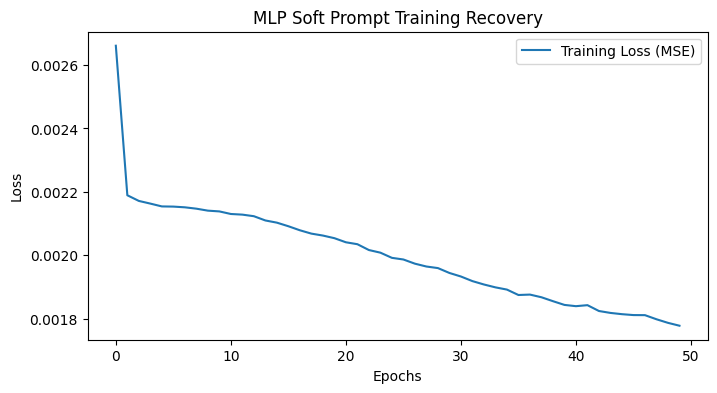

In [9]:
# > 呼叫 MLP 訓練腳本
from scripts.train_mlp import train_soft_prompt_mlp
import matplotlib.pyplot as plt

# 執行預訓練 (映射數值特徵到嵌入空間)
model, loss_history = train_soft_prompt_mlp(
    df_processed, 
    df_pca, 
    meta_path="data/spotify_meta.pkl", 
    epochs=50
)

# 視覺化訓練 Loss 曲線
plt.figure(figsize=(8, 4))
plt.plot(loss_history, label="Training Loss (MSE)")
plt.title("MLP Soft Prompt Training Recovery")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


## 透過 [DATA 1 & 2] 訓練 MLP (Fine-tuning) (優選)

### 輸入(X): 偽共現關係 / 用戶畫像

### 目標(Y): 推薦歌曲

// @ 偵測到現有的微調模型: data/soft_prompt_mlp_finetuned.pth，直接載入...


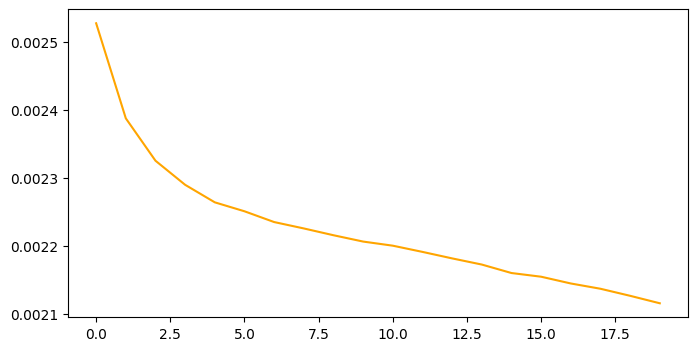

In [10]:
# > 呼叫 MLP 微調腳本
from scripts.finetune_mlp import finetune_soft_prompt_mlp

# 執行微調 (讓模型學會 Persona 的具體品味)
ft_model, ft_loss_history = finetune_soft_prompt_mlp(
    df_processed, 
    df_pca, 
    base_model_path="data/soft_prompt_mlp.pth", 
    output_path="data/soft_prompt_mlp_finetuned.pth", 
    epochs=20
)

# 視覺化微調 Loss 曲線
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(ft_loss_history, color="orange", label="Fine-tuning Loss")
# ... (顯示 Loss 曲線)


## 透過 MLP 將所有歌曲都轉為向量並存字典（Dictionary）

In [11]:
# > 呼叫批次預測腳本
from scripts.batch_predict_embeddings import batch_generate_soft_prompts

# 使用微調後的模型產生所有歌曲的語義向量地圖',
soft_prompts_map = batch_generate_soft_prompts(
    df_processed,
    df_pca,
    model_path="data/soft_prompt_mlp_finetuned.pth",
    output_path="data/soft_prompts_map.pkl"
)

# 檢查成果',
sample_id = list(soft_prompts_map.keys())[0]
print(f"Sample Track ID: {sample_id}")
print(f"Vector Dimension: {len(soft_prompts_map[sample_id])}")

// > 已載入模型: data/soft_prompt_mlp_finetuned.pth，準備轉換 1989 首歌曲...
// !! 數據維度 (21) 與模型維度 (20) 不符，進行自動對齊...
// > 正在進行批次預測 (Inference)...
// @ 語義向量字典建置完成！已存至: data/soft_prompts_map.pkl
   - 總歌曲數: 1978
Sample Track ID: 6KwkVtXm8OUp2XffN5k7lY
Vector Dimension: 384


# 推薦流程

## 選擇 persona 並透過 MLP 轉成 Soft Prompt

In [12]:
# > 從畫像歷史中提取語義重心 (Soft Prompt)
from scripts.get_persona_prompt import get_persona_soft_prompt, list_available_personas

# 1. 列出可用的畫像
available_personas = list_available_personas()
print(f"Available Personas: {available_personas}")

# 2. 選擇一個畫像進行推薦模擬 (例如 Party Animal)
target_persona = "Party Animal"
if target_persona in available_personas:
    # 提取該畫像的平均預測向量 (Soft Prompt)
    persona_soft_prompt = get_persona_soft_prompt(target_persona, soft_prompts_map)
    
    print(f"\n--- {target_persona} Soft Prompt Summary ---")
    print(f"Vector Mean: {persona_soft_prompt.mean():.4f}")
    print(f"Vector Max: {persona_soft_prompt.max():.4f}")
else:
    print(f"Error: {target_persona} not found.")


Available Personas: ['Chill Vibes', 'Party Animal', 'Study Focus', 'Workout Motivation']
// @ 成功計算畫像 'Party Animal' 的 Soft Prompt
   - 引用歷史歌曲數: 20 / 20
   - 代表性歌曲: Jackie Chan, Chop (Nouvelle École), Stir Me Up...

--- Party Animal Soft Prompt Summary ---
Vector Mean: 0.0005
Vector Max: 0.0853


## 隨機播放一首歌曲並透過 MLP 轉成 Soft Prompt

In [13]:
# > 隨機選一首「當前播放歌曲」並獲取其語義向量
import numpy as np

# 隨機取一首歌曲 ID
current_song_id = np.random.choice(list(soft_prompts_map.keys()))
current_song_details = next(m for m in metadata if m['track_id'] == current_song_id)

# 獲取該曲的 MLP 預測向量 (Soft Prompt)
current_song_soft_prompt = soft_prompts_map[current_song_id]

print(f"Current Playing: {current_song_details['track_name']} by {current_song_details['artists']}")
print(f"Current Song Vector Summary: Mean={current_song_soft_prompt.mean():.4f}")


Current Playing: Leave Before The Lights Come On by Arctic Monkeys
Current Song Vector Summary: Mean=0.0004


## 長期偏好總結搜尋

In [14]:
# > 讀取 LLM 產出的畫像文字總結 (來自 DATA 2)
import json
import os

summary_path = "data/persona_listening_histories/persona_summaries.json"
if os.path.exists(summary_path):
    with open(summary_path, "r", encoding="utf-8") as f:
        persona_summaries = json.load(f)
    current_persona_summary = persona_summaries.get(target_persona, "無特定偏好總結。")
    print(f"--- {target_persona} 長期偏好總結 ---")
    print(current_persona_summary)
else:
    print("尚未生成畫像總結。")


--- Party Animal 長期偏好總結 ---
1. **偏好舞曲電子音樂**：用戶的聽歌清單中多數歌曲屬於電子舞曲類型，如 house、deep-house 和 electro，顯示其對電子音樂的強烈偏好。

2. **多樣化的曲風接受度**：用戶的音樂偏好涵蓋多種曲風，包括 ska、j-idol、forro 和 disco，展現其對不同音樂類型的開放態度。

3. **重視節奏感與舞動性**：選擇的歌曲多數具有強烈的節奏感和舞動性，適合派對和舞池環境，顯示用戶對快節奏和能量滿滿的音樂的喜愛。

4. **國際化音樂品味**：用戶收聽來自不同國家的音樂，包括法國、土耳其、日本和巴西等地的作品，反映出其對國際音樂的興趣。

5. **偏好正能量與愉悅氛圍**：選擇的歌曲通常營造出愉悅或令人振奮的氛圍，表明用戶可能偏好正能量和積極向上的音樂內容。


## 數值特徵檢索

In [15]:
# > 執行數值特徵檢索 (Numerical/Pre-computed Retrieval)
import json

# 從先前計算好的相似矩陣中獲取候選歌曲
current_song_sim_items = next((item for item in all_similar_songs if item["track_id"] == current_song_id), None)

numerical_candidates = []
if current_song_sim_items:
    # 獲取前 10 首相似歌曲
    numerical_candidates = current_song_sim_items.get('top_n_similar_songs', [])
    print(f"--- 數值特徵檢索結果 (基於原始歌曲) ---")
    for i, sim_song in enumerate(numerical_candidates):
        sim_val = sim_song.get('similarity_score', 0.0)
        # 檢查是否為數值，若是則格式化，否則直接印出
        sim_str = f"{sim_val:.4f}" if isinstance(sim_val, (int, float)) else "N/A"
        print(f"{i+1}. {sim_song['track_name']} by {sim_song['artists']} (Similarity: {sim_str})")
else:
    print("找不到當前歌曲的數值相似候選清單。")


--- 數值特徵檢索結果 (基於原始歌曲) ---
1. Mer O Mer O Mer by Hjalle & Heavy (Similarity: 0.9646)
2. Cold by Static-X (Similarity: 0.9390)
3. Got The Power by Eagles Of Death Metal (Similarity: 0.9092)
4. Summer Of '69 by Bryan Adams (Similarity: 0.8602)
5. Rock and Roll - Remaster by Led Zeppelin (Similarity: 0.8418)
6. Pa' Madrid by El Barrio (Similarity: 0.8325)
7. Mi Error by Adolescent's Orquesta (Similarity: 0.8316)
8. 僕は君の答えになりたいな by Creep Hyp (Similarity: 0.8277)
9. =LOVE by =LOVE (Similarity: 0.8253)
10. Spoonman by Soundgarden (Similarity: 0.8219)


## 語義檢索

In [16]:
# > 執行語義檢索 (Semantic Retrieval via FAISS)
import faiss
import numpy as np

# 1. 準備查詢向量 (使用當前歌曲的 MLP 預測向量)
# 同時為了對齊 FAISS 維度，我們將其擴張為 (1, 384) 的 numpy array
query_vector = current_song_soft_prompt.reshape(1, -1).astype('float32')

# 2. 進行搜尋 (找前 10 名)
distances, indices = index.search(query_vector, k=11) # 多抓一個以防包含自己

semantic_candidates = []
print(f"--- 語義檢索結果 (基於 MLP 預測向量) ---")
for i, idx in enumerate(indices[0]):
    # 排除掉當前正在播放的歌曲本身
    if metadata[idx]['track_id'] == current_song_id:
        continue
    
    candidate = metadata[idx]
    semantic_candidates.append(candidate)
    
    # 僅顯示前 10 個
    if len(semantic_candidates) <= 10:
        print(f"{len(semantic_candidates)}. {candidate['track_name']} by {candidate['artists']} (Dist: {distances[0][i]:.4f})")


--- 語義檢索結果 (基於 MLP 預測向量) ---
1. Só Mais uma Vez - Ao Vivo by Leonardo;Eduardo Costa (Dist: 0.1947)
2. Vai Mudar (feat. João Santana) by Irmão Lázaro;João Santana (Dist: 0.1947)
3. Flow Natural by Tito "El Bambino";Beenie Man;Ines (Dist: 0.1946)
4. When The Lights Go Down by DJ Snake (Dist: 0.1936)
5. Quedemonos Aqui - En Vivo by Ariel Ardit;Andrés Linetzky (Dist: 0.1927)
6. Amor Ausente (En Vivo) (with Abel Pintos) by Eruca Sativa;Abel Pintos (Dist: 0.1920)
7. Proibida Pra Mim (Grazon) - Ao Vivo by Charlie Brown Jr. (Dist: 0.1907)
8. No Soy Automático by Hector Tricoche (Dist: 0.1894)
9. Arcoíris by J Balvin;Mr Eazi (Dist: 0.1893)
10. Carpinteiro do universo by Marcelo Nova;Raul Seixas (Dist: 0.1892)


## 整合所有結果: [persona Soft Prompt] + [數值特徵檢索] + [語義檢索] 

In [17]:
# > 整合所有檢索結果並進行 Agentic Re-ranking
from scripts.recommender_agent import calculate_cosine_similarity

# 1. 整合候選名單 (去重)
all_candidates_dict = {}

# 1.1 加入數值檢索候選人 (來自 DATA 1)
# 由於 numerical_candidates 只有基本資訊，我們需要補齊 metadata
for c in numerical_candidates:
    tid = c['track_id']
    full_meta = next((m for m in metadata if m['track_id'] == tid), None)
    if full_meta:
        all_candidates_dict[tid] = full_meta

# 1.2 加入語義檢索候選人 (來自 DATA 3/FAISS)
for c in semantic_candidates:
    all_candidates_dict[c['track_id']] = c

# 2. 為候選歌曲計算與 Persona Soft Prompt 的相似度
# 這能幫助 LLM 判斷哪首歌在「語義空間」中更靠近畫像的品味中心
final_candidate_list = []
for tid, meta in all_candidates_dict.items():
    if tid in soft_prompts_map:
        sim_score = calculate_cosine_similarity(persona_soft_prompt, soft_prompts_map[tid])
        meta_with_score = meta.copy()
        meta_with_score['persona_match_score'] = float(sim_score)
        final_candidate_list.append(meta_with_score)


## 代理人協作推理與重排序

In [18]:
# > 進行多模型 Agentic 推薦與品味對比
from scripts.recommender_agent import get_multi_model_recommendations, calculate_cosine_similarity

# 3. 啟動多模型並行推理 (會同時呼叫 GPT-4o, Gemini 2.0, Grok-2)
print(f"// > 正在為 {target_persona} 生成代理人推薦 (候選歌曲數: {len(final_candidate_list)})...")
multi_results, errors = get_multi_model_recommendations(
    target_persona, 
    current_song_details, 
    current_persona_summary, 
    final_candidate_list
)

# 4. 展示對比結果
if errors:
    print(f"部分模型執行錯誤: {errors}")

for model_name, result in multi_results.items():
    print(f"\n{'='*20} 🤖 {model_name} 推薦報告 {'='*20}")
    print(f"策略摘要: {result['agent_explanation']}\n")
    for i, rec in enumerate(result['recommendations']):
        print(f"   [{i+1}] {rec['track_name']} - {rec['artists']}")
        print(f"       💡 理由: {rec['reason']}")
    print("\n")


// > 正在為 Party Animal 生成代理人推薦 (候選歌曲數: 21)...
// > 正在請求 GPT-4o...// > 正在請求 Gemini-2.0-Flash...

// > 正在請求 Grok 4.1 Fast...

==================== 🤖 Gemini-2.0-Flash 推薦報告 ====================
策略摘要: 基於您對舞曲電子音樂的偏好、多樣化的曲風接受度、以及重視節奏感的特點，我為您推薦了這五首歌曲。這些歌曲涵蓋電子、J-Idol、Punk、Garage Rock和 J-Pop等多種風格，都具有Energetic和Fast Tempo的特點，希望能夠滿足您派對動物的音樂需求，讓您在派對中盡情享受。

   [1] When The Lights Go Down - DJ Snake
       💡 理由: 作為舞曲電子音樂，這首歌由知名 DJ Snake 演出，節奏約 160 BPM，保證派對氣氛。
   [2] =LOVE - =LOVE
       💡 理由: 考慮到您對 J-Idol 的接受度，這首歌能量滿滿 (Energy 0.96)，非常適合炒熱氣氛。
   [3] Mer O Mer O Mer - Hjalle & Heavy
       💡 理由: 這首 Punk 歌曲節奏輕快 (147 BPM)，Cheerful, Energetic的氛圍能帶來愉悅感受。
   [4] Got The Power - Eagles Of Death Metal
       💡 理由: 這首 Garage 搖滾歌曲充滿能量，Fast Tempo的節奏保證讓你舞動起來。
   [5] 僕は君の答えになりたいな - Creep Hyp
       💡 理由: 加入一首 J-Pop ，170 BPM能讓你的舞池更多元。



==================== 🤖 GPT-4o 推薦報告 ====================
策略摘要: 根據用戶偏好（Party Animal），選擇了具高能量、快速節奏且正能量氛圍的歌曲，且涵蓋多樣化的音樂風格，以滿足用戶的國際化音樂品味與派對需求。

   [1] When The Lights Go Down - DJ Snake
  

## Embedding Space Visualization

In [19]:
%run scripts/notebook_visualization.py

// > 正在讀取資料並準備繪圖...


// @ 視覺化完成，互動式圖表已儲存至 data/embedding_space_viz.html
